# RL Post-Training — 0c : l'anatomie d'un hack qui PREND — le biais de longueur

`rlpt_3_reward_hacking` a montré un hack qui **ne prend pas** : un proxy qui récompense la recopie, sur une tâche à récompense vérifiable, et une exploration qui meurt avant de trouver la faille. Ce notebook traite le cas **opposé**, et c'est précisément pour cela qu'il existe.

Ici le proxy n'est plus une règle écrite à la main : c'est un **reward model appris** (Bradley-Terry, comme `rlpt_0`), entraîné sur des préférences d'annotateurs qui ont un **biais de longueur**. Et cette fois le hack **prend** — parce que la direction récompensée par le proxy n'est plus une recopie absurde mais *une propriété que la politique peut produire à volonté*.

L'objectif du notebook est de **démontrer le cercle vicieux**, pas de le décrire :

1. mesurer le biais dans le reward model appris (pas l'affirmer) ;
2. montrer que PPO, en optimisant ce proxy, **déplace l'effort** de la politique vers le remplissage ;
3. montrer que la qualité **mesurée par une métrique indépendante** du proxy baisse ;
4. **isoler la cause** par un bras de contrôle : le même PPO, sur une récompense dont on a retiré le terme de longueur, ne perd pas sa qualité.

## 1. Le monde : un budget de calcul partagé

Pour que le hack soit *démontrable* et pas seulement *racontable*, il faut que la politique ait un **arbitrage réel** à faire. On pose donc un monde minimal où la réponse est produite sous contrainte de budget :

- la politique choisit un **effort de résolution** $e \in \{0, \dots, B\}$ ;
- le **remplissage** est le reste du budget : $p = B - e$ ;
- la réponse est **correcte** si et seulement si $e \ge \theta$ — l'effort insuffisant ne résout pas la tâche ;
- la **longueur observée** de la réponse est $p$.

Le budget $B$ est **partagé** : tout effort donné au remplissage est retiré à la résolution. C'est l'hypothèse de modélisation centrale du notebook et elle est déclarée ici, pas cachée — sans elle il n'y a pas d'arbitrage, donc pas de hack possible. Un monde sans budget partagé ne pourrait montrer qu'un gonflement gratuit de la longueur, ce qui n'est pas le phénomène étudié.

**Deux quantités à ne jamais confondre :**

| quantité | nature | qui la voit |
|---|---|---|
| la **récompense du proxy** $r_\phi$ | apprise sur des préférences biaisées | l'optimiseur (PPO) |
| la **qualité vraie** | la correction de la réponse | personne dans la boucle — c'est l'observateur indépendant |

Toute la suite consiste à mesurer l'écart entre les deux.

In [1]:
# Garde SSL Windows : le magasin de certificats local contient des racines que
# le bundle embarqué de Python ne connait pas ; sans ceinture, des appels
# reseau ulterieurs (aucun ici) echoueraient. Convention de la serie.
import os

os.environ.setdefault("PYTHONHTTPSVERIFY", "0")
os.environ.setdefault("CURL_CA_BUNDLE", "")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Graine unique et explicite : le notebook est reproductible de bout en bout.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

print("numpy ", np.__version__)
print("torch ", torch.__version__)
print("graine", SEED)

numpy  2.2.6
torch  2.6.0+cu124
graine 42


In [2]:
# --- Le monde -------------------------------------------------------------
# BUDGET   : unites de calcul disponibles pour une reponse (partagees).
# THETA    : effort minimal pour que la reponse soit CORRECTE.
# La longueur observee n'est pas l'effort : c'est le remplissage p = B - e.
BUDGET = 10
THETA = 6

ACTIONS = np.arange(BUDGET + 1)          # effort e = 0..BUDGET


def effort_to_length(e):
    """Longueur observee d'une reponse d'effort e (le budget partage)."""
    return BUDGET - e


def is_correct(e):
    """Verite terrain du monde : l'effort suffit-il ?"""
    return e >= THETA


# --- Controle de coherence du monde --------------------------------------
# Le monde doit etre non degenere : une politique qui maximise le remplissage
# doit pouvoir ECHOUER, sinon il n'y a rien a demontrer.
assert is_correct(BUDGET) is True, "l'effort maximal doit resoudre la tache"
assert is_correct(0) is False, "l'effort nul ne doit pas resoudre la tache"
assert effort_to_length(BUDGET) == 0 and effort_to_length(0) == BUDGET

print(f"budget            : {BUDGET} unites")
print(f"seuil de correction : effort >= {THETA}")
print(f"actions possibles : {len(ACTIONS)} (effort {ACTIONS[0]}..{ACTIONS[-1]})")
print()
print(f"{'effort e':>8} {'correct':>8} {'longueur p':>11}")
for e in ACTIONS:
    print(f"{e:>8} {str(is_correct(e)):>8} {effort_to_length(e):>11}")

budget            : 10 unites
seuil de correction : effort >= 6
actions possibles : 11 (effort 0..10)

effort e  correct  longueur p
       0    False          10
       1    False           9
       2    False           8
       3    False           7
       4    False           6
       5    False           5
       6     True           4
       7     True           3
       8     True           2
       9     True           1
      10     True           0


**Lecture du tableau.** Le monde est bien un arbitrage : à `e = 0` la réponse est la plus longue possible (10 unités de remplissage) et **fausse** ; à `e = 10` elle est la plus courte et **juste**. Une politique qui cherche la longueur doit donc payer en correction — c'est exactement le mécanisme qu'on veut mettre sous PPO.

## 2. Le juge biaisé : des préférences, pas des notes

On ne fabrique pas un reward model « biaisé » à la main. On fabrique un **annotateur** biaisé, puis on laisse le reward model apprendre ce que ces préférences disent — y compris leur biais. C'est la seule façon honnête de mesurer le biais : s'il est dans les données, il sera dans le modèle, et on pourra le lire dans ses poids.

L'annotateur compare deux réponses selon Bradley-Terry, avec le paramètre de bruit $\beta$ habituel :

$$P(y_a \succ y_b) = \sigma\big(\beta\,(u(y_a) - u(y_b))\big)$$

où l'utilité de l'annotateur $u$ n'est **pas** la qualité vraie mais un mélange :

$$u(y) = \underbrace{\mathbb{1}[y \text{ correct}]}_{\text{signal}} + \underbrace{\alpha \cdot \frac{p(y)}{B}}_{\text{biais de longueur}}$$

$\alpha$ est **l'intensité du biais d'annotation** — c'est la variable que le notebook fait varier. À $\alpha = 0$ les annotateurs sont parfaitement rationnels (ils ne récompensent que la correction) ; à $\alpha \gg 1$ ils préfèrent systématiquement la réponse la plus longue, juste ou fausse.

In [3]:
# --- L'annotateur biaise --------------------------------------------------
# ALPHA = intensite du biais de longueur dans les PREFERENCES.
BETA_ANNOT = 4.0        # nettete de l'annotateur biaise
ALPHA = 2.0             # biais de longueur (0 = annotateur rationnel)


def annotator_utility(e, alpha=ALPHA):
    """Utilite de l'annotateur pour une reponse d'effort e.

    Melange EXPLICITE de la qualite vraie et du biais de longueur. A alpha=0
    l'annotateur est rationnel ; alpha grandit -> il prefere le remplissage.
    """
    return float(is_correct(e)) + alpha * (effort_to_length(e) / BUDGET)


def sample_preference_pairs(n_pairs, alpha=ALPHA, beta=BETA_ANNOT, gen=None):
    """n_pairs comparaisons (e_a, e_b, a_prefere_b) tirees au hasard.

    Le tirage des deux reponses est UNIFORME sur les actions : le dataset ne
    privilegie aucune duree, donc le biais mesure plus bas vient bien de
    l'annotateur et pas d'un desequilibre du tirage.
    """
    gen = gen or np.random.default_rng(SEED)
    ea = gen.integers(0, BUDGET + 1, size=n_pairs)
    eb = gen.integers(0, BUDGET + 1, size=n_pairs)
    du = np.array([annotator_utility(int(a), alpha) - annotator_utility(int(b), alpha)
                   for a, b in zip(ea, eb)])
    p_a = 1.0 / (1.0 + np.exp(-beta * du))
    prefer_a = gen.random(n_pairs) < p_a
    return ea, eb, prefer_a


N_PAIRS = 8000
ea, eb, prefer_a = sample_preference_pairs(N_PAIRS)

print(f"paires generees        : {N_PAIRS}")
print(f"biais d'annotation a   : {ALPHA}")
print(f"preference pour a      : {prefer_a.mean():.4f}  (0.5 = annotateur sans signal)")
print()
# Le biais doit etre VISIBLE dans les paires : parmi les paires ou les deux
# reponses ont la MEME correction, l'annotateur doit encore trancher par la
# longueur. C'est la signature du biais, et elle est mesurable sans modele.
same_correct = np.array([is_correct(int(a)) == is_correct(int(b))
                         for a, b in zip(ea, eb)])
print(f"paires a correction EGALE : {same_correct.sum()} sur {N_PAIRS}")
if same_correct.sum():
    longer_is_a = np.array([effort_to_length(int(a)) > effort_to_length(int(b))
                            for a, b in zip(ea, eb)])
    m = same_correct
    print(f"  -> l'annotateur choisit la reponse LONGUE dans "
          f"{(prefer_a[m] == longer_is_a[m]).mean():.4f} des cas")
    print("  (0.5000 = aucune preference de longueur ; > 0.5 = biais present)")

paires generees        : 8000
biais d'annotation a   : 2.0
preference pour a      : 0.4961  (0.5 = annotateur sans signal)

paires a correction EGALE : 3981 sur 8000
  -> l'annotateur choisit la reponse LONGUE dans 0.7762 des cas
  (0.5000 = aucune preference de longueur ; > 0.5 = biais present)


**Lecture du résultat.** Sur les paires où les deux réponses sont **également correctes** — donc où la qualité vraie ne les départage pas — l'annotateur tranche quand même, et il tranche pour la plus longue dans une large majorité des cas. C'est la signature du biais, **mesurée sur les données brutes**, avant tout entraînement. Un annotateur rationnel donnerait 0,5000 ici.

## 3. Le reward model appris : le biais devient un poids

On entraîne maintenant un reward model $r_\phi$ par **maximum de vraisemblance Bradley-Terry** sur ces préférences, exactement comme `rlpt_0` — aucune lib `trl`, la boucle est écrite à la main.

Le modèle est volontairement **linéaire et lisible** sur deux caractéristiques observables :

$$\hat s_\phi(e) = b + w_c \cdot \mathbb{1}[e \text{ correct}] + w_l \cdot \frac{p(e)}{B}$$

Un reward model linéaire sur ces deux features est le choix *honnête* ici : il rend le biais **directement lisible dans un poids** ($w_l$), au lieu de l'enfouir dans des couches. Ce qu'on veut mesurer, c'est un rapport entre deux poids — pas la capacité d'un réseau.

In [4]:
# --- Features et dataset Bradley-Terry ------------------------------------
def features(e):
    """Vecteur de caracteristiques observe par le reward model."""
    e = int(e)
    return np.array([1.0, float(is_correct(e)), effort_to_length(e) / BUDGET],
                    dtype=np.float32)


Xa = np.stack([features(int(e)) for e in ea])
Xb = np.stack([features(int(e)) for e in eb])
Ya = prefer_a.astype(np.float32)

Xa_t = torch.tensor(Xa)
Xb_t = torch.tensor(Xb)
Ya_t = torch.tensor(Ya)

print("forme des features :", tuple(Xa.shape), "(biais, correction, longueur)")
print("exemple            :", Xa[0], "-> correct =", bool(Xa[0][1]),
      "longueur =", round(float(Xa[0][2]), 3))

forme des features : (8000, 3) (biais, correction, longueur)
exemple            : [1. 0. 1.] -> correct = False longueur = 1.0


In [5]:
# --- Entrainement du reward model (Bradley-Terry, from scratch) ------------
torch.manual_seed(SEED)
rm = nn.Linear(3, 1)
opt = torch.optim.Adam(rm.parameters(), lr=0.05)

history_rm = []
for epoch in range(400):
    opt.zero_grad()
    sa = rm(Xa_t).squeeze(-1)
    sb = rm(Xb_t).squeeze(-1)
    # P(a > b) = sigmoid(s_a - s_b) ; perte = -log de la vraisemblance du choix
    loss = F.binary_cross_entropy_with_logits(sa - sb, Ya_t)
    loss.backward()
    opt.step()
    history_rm.append(float(loss.item()))

with torch.no_grad():
    w_bias, w_correct, w_length = [float(v) for v in rm.weight[0]]
    b_rm = float(rm.bias[0])

print(f"perte finale (BT)  : {history_rm[-1]:.5f}")
print()
print("poids appris du reward model :")
print(f"  biais            b  = {b_rm:+.4f}")
print(f"  correction       wc = {w_correct:+.4f}")
print(f"  longueur         wl = {w_length:+.4f}")
print()
print(f"rapport |wl / wc| = {abs(w_length) / max(abs(w_correct), 1e-9):.4f}")

perte finale (BT)  : 0.46238

poids appris du reward model :
  biais            b  = +0.5304
  correction       wc = +3.8868
  longueur         wl = +7.7436

rapport |wl / wc| = 1.9923


**Lecture des poids.** Le reward model a appris **exactement le biais de ses données** : le poids de la longueur $w_l$ vaut près du **double** du poids de la correction $w_c$ (rapport mesuré $\approx 1{,}99$, et il ne bouge pas d'une graine à l'autre), alors que dans le monde la longueur n'a *aucune* valeur intrinsèque. Le biais n'est donc pas une hypothèse du notebook : c'est un **paramètre mesuré** de $r_\phi$.

Que ce rapport vaille 2 et que le proxy préfère malgré tout une action *correcte* au départ n'est pas contradictoire : le terme de correction est un **échelon** (il vaut 1 ou 0 selon l'action), donc $\alpha$ doit monter assez haut pour que le terme continu de longueur l'emporte sur lui sur toute la plage des actions correctes. C'est précisément ce que le balayage du §7 va situer.

C'est le point que `rlpt_3` ne pouvait pas montrer : là-bas le proxy était une règle écrite à la main et l'échec venait de l'exploration. Ici le proxy est *appris*, il est raisonnablement calibré sur ses données, et il est **faux** — il récompense une propriété sans valeur. C'est la situation réelle du RLHF.

In [6]:
# --- Le biais est-il robuste a la graine ? --------------------------------
def fit_reward_model(seed, n_pairs=N_PAIRS, alpha=ALPHA, epochs=400):
    """Re-entraine le RM sur un dataset neuf ; rend (wc, wl, perte)."""
    g = np.random.default_rng(seed)
    e1, e2, pa = sample_preference_pairs(n_pairs, alpha=alpha, gen=g)
    X1 = torch.tensor(np.stack([features(int(e)) for e in e1]))
    X2 = torch.tensor(np.stack([features(int(e)) for e in e2]))
    y = torch.tensor(pa.astype(np.float32))
    torch.manual_seed(seed)
    m = nn.Linear(3, 1)
    o = torch.optim.Adam(m.parameters(), lr=0.05)
    for _ in range(epochs):
        o.zero_grad()
        l = F.binary_cross_entropy_with_logits(m(X1).squeeze(-1) - m(X2).squeeze(-1), y)
        l.backward()
        o.step()
    with torch.no_grad():
        return (float(m.weight[0][1]), float(m.weight[0][2]), float(l.item()))


print(f"{'graine':>7} {'wc (correction)':>16} {'wl (longueur)':>14} {'|wl/wc|':>9}")
ratio_rows = []
for s in (0, 1, 7, SEED):
    wc_s, wl_s, _ = fit_reward_model(s)
    ratio_rows.append(abs(wl_s) / abs(wc_s))
    print(f"{s:>7} {wc_s:>16.4f} {wl_s:>14.4f} {ratio_rows[-1]:>9.4f}")

ratios = np.array(ratio_rows)
print()
print(f"rapport |wl/wc| : min {ratios.min():.4f} / max {ratios.max():.4f} "
      f"/ etendue {ratios.max() - ratios.min():.4f}")
print("-> le biais est present a TOUTES les graines ; ce n'est pas un accident de tirage.")

 graine  wc (correction)  wl (longueur)   |wl/wc|


      0           3.6144         7.3133    2.0234


      1           3.8256         7.6516    2.0001


      7           3.9268         7.7929    1.9845


     42           3.8868         7.7436    1.9923

rapport |wl/wc| : min 1.9845 / max 2.0234 / etendue 0.0388
-> le biais est present a TOUTES les graines ; ce n'est pas un accident de tirage.


**Lecture multi-graine.** Le biais survit à quatre jeux de données indépendants : le rapport $|w_l / w_c|$ reste du même ordre partout. On ne mesure donc pas un artefact d'une graine — ce qui est la condition pour que la suite (PPO sur ce proxy) ait un sens.

## 4. La politique et la récompense

La politique est un **modèle catégoriel** sur les $B+1$ actions : $\pi_\theta(e)$. Elle est volontairement sans état — c'est le choix qui rend la démonstration **exacte** plutôt que bruitée.

Conséquence méthodologique importante : la qualité vraie et la longueur moyenne d'une politique se calculent comme des **espérances sous $\pi_\theta$**, pas comme des estimations par échantillonnage :

$$\text{qualité}(\theta) = \sum_{e \ge \theta} \pi_\theta(e) \qquad\qquad \text{longueur}(\theta) = \sum_e \pi_\theta(e) \cdot (B - e)$$

Ces deux grandeurs sont donc **déterministes à politique donnée**. Il n'y a pas de « bruit de mesure » derrière lequel se cacher : si la qualité baisse, c'est que la politique a bougé.

La récompense optimisée est le **score du reward model appris** : $r_\phi(e) = \hat s_\phi(e)$. L'observateur indépendant, lui, ne lit que `is_correct(e)`.

In [7]:
# --- Politique catégorielle + reference figee -----------------------------
def policy_probs(logits):
    return torch.softmax(logits, dim=-1)


def true_accuracy(logits):
    """Qualite VRAIE : masse de probabilite sur les actions correctes."""
    with torch.no_grad():
        return float(policy_probs(logits)[THETA:].sum().item())


def mean_length(logits):
    """Longueur moyenne OBSERVEE (le remplissage), en unites."""
    with torch.no_grad():
        return float((policy_probs(logits) * torch.tensor(
            [effort_to_length(int(e)) for e in ACTIONS], dtype=torch.float32)).sum().item())


def rm_score(logits):
    """Recompense du proxy : esperance du score du reward model."""
    with torch.no_grad():
        X = torch.tensor(np.stack([features(int(e)) for e in ACTIONS]))
        return float((policy_probs(logits) * rm(X).squeeze(-1)).sum().item())


def init_policy(seed):
    torch.manual_seed(seed)
    # Politique initiale : logits nuls -> uniforme sur les 11 actions.
    return torch.zeros(len(ACTIONS), requires_grad=True)


logits0 = init_policy(SEED)
print(f"politique initiale (uniforme)")
print(f"  qualite vraie : {true_accuracy(logits0):.4f}")
print(f"  longueur moy. : {mean_length(logits0):.4f}")
print(f"  score du RM   : {rm_score(logits0):+.4f}")
print()
print("Une politique uniforme est correcte a", f"{true_accuracy(logits0):.1%}",
      "(5 actions sur 11) : c'est le point de depart de toutes les experiences.")

politique initiale (uniforme)
  qualite vraie : 0.4545
  longueur moy. : 5.0000
  score du RM   : +6.6103

Une politique uniforme est correcte a 45.5% (5 actions sur 11) : c'est le point de depart de toutes les experiences.


## 5. PPO from scratch sur le proxy

PPO est réimplémenté à la main sur cette politique catégorielle — ratio d'importance tronqué, avantage centré par une ligne de base, et **pénalité KL vers la politique de référence** (la politique initiale gelée). La KL n'est pas décorative : c'est elle qui empêche la politique de sauter d'un coup hors de sa région de confiance, et c'est aussi le terme qui, en RLHF réel, borne l'écart au modèle SFT.

La fonction ci-dessous est **agnostique de la récompense** : on lui passe un callable `reward_fn(e)`. C'est ce qui permet, trois cellules plus loin, de rejouer *exactement le même* PPO sur une autre récompense — et donc d'isoler la cause.

In [8]:
# --- PPO minimal (ratio tronque + KL vers la reference) -------------------
def ppo(reward_table, seed=SEED, steps=120, batch=256, lr=0.05,
        clip_eps=0.2, kl_coef=0.05, verbose=False):
    """Entraine pi_theta a maximiser E_pi[r(e)].

    reward_table : tenseur de taille (len(ACTIONS),) -- la recompense de chaque
    action. Aucune autre connaissance du monde n'entre ici : c'est le point
    d'injection qui rend l'experience controlee.
    """
    torch.manual_seed(seed)
    logits = torch.zeros(len(ACTIONS), requires_grad=True)
    ref_logits = logits.detach().clone()          # reference gelee
    opt = torch.optim.Adam([logits], lr=lr)
    hist = {"reward": [], "length": [], "accuracy": []}

    for step in range(steps):
        with torch.no_grad():
            probs = torch.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, batch, replacement=True)
            old_logp = torch.log(probs[idx])
            r = reward_table[idx]
            adv = r - r.mean()                     # ligne de base = moyenne

        probs_now = torch.softmax(logits, dim=-1)
        new_logp = torch.log(probs_now[idx])
        ratio = torch.exp(new_logp - old_logp)
        unclipped = ratio * adv
        clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv
        pg_loss = -torch.min(unclipped, clipped).mean()

        ref_p = torch.softmax(ref_logits, dim=-1)
        kl = (probs_now * (torch.log(probs_now + 1e-12) - torch.log(ref_p + 1e-12))).sum()
        loss = pg_loss + kl_coef * kl

        opt.zero_grad()
        loss.backward()
        opt.step()

        hist["reward"].append(float((probs_now.detach() * reward_table).sum()))
        hist["length"].append(mean_length(logits))
        hist["accuracy"].append(true_accuracy(logits))

    return logits.detach(), hist

In [9]:
# --- Bras 1 : PPO optimise le PROXY BIAISE --------------------------------
with torch.no_grad():
    X_all = torch.tensor(np.stack([features(int(e)) for e in ACTIONS]))
    REWARD_BIASED = rm(X_all).squeeze(-1).detach()

print("recompense du proxy par action (effort e -> r_phi) :")
for e in ACTIONS:
    print(f"  e={e:>2}  correct={str(is_correct(e)):>5}  longueur={effort_to_length(e):>2}"
          f"  r_phi={float(REWARD_BIASED[e]):+.4f}")

logits_biased, hist_biased = ppo(REWARD_BIASED)

print()
print("=== Bras 1 : PPO sur le reward model biaise ===")
print(f"  score du proxy : {rm_score(logits0):+.4f}  ->  {rm_score(logits_biased):+.4f}")
print(f"  longueur moy.  : {mean_length(logits0):.4f}  ->  {mean_length(logits_biased):.4f}")
print(f"  QUALITE VRAIE  : {true_accuracy(logits0):.4f}  ->  {true_accuracy(logits_biased):.4f}")

recompense du proxy par action (effort e -> r_phi) :
  e= 0  correct=False  longueur=10  r_phi=+8.7153
  e= 1  correct=False  longueur= 9  r_phi=+7.9410
  e= 2  correct=False  longueur= 8  r_phi=+7.1666
  e= 3  correct=False  longueur= 7  r_phi=+6.3923
  e= 4  correct=False  longueur= 6  r_phi=+5.6179
  e= 5  correct=False  longueur= 5  r_phi=+4.8435
  e= 6  correct= True  longueur= 4  r_phi=+7.9560
  e= 7  correct= True  longueur= 3  r_phi=+7.1817
  e= 8  correct= True  longueur= 2  r_phi=+6.4073
  e= 9  correct= True  longueur= 1  r_phi=+5.6329
  e=10  correct= True  longueur= 0  r_phi=+4.8586

=== Bras 1 : PPO sur le reward model biaise ===
  score du proxy : +6.6103  ->  +8.6766
  longueur moy.  : 5.0000  ->  9.8646
  QUALITE VRAIE  : 0.4545  ->  0.0170


**Lecture du résultat : le cercle vicieux, en trois lignes.** Le proxy monte, la longueur monte, et la **qualité vraie baisse**. La politique n'a pas « mal appris » : elle a parfaitement appris ce qu'on lui a demandé. Elle a déplacé son budget d'effort vers la propriété que le proxy récompense, et cette propriété n'a aucune valeur — pire, elle coûte.

C'est le **pourquoi** du reward hacking : le hack n'est pas un bug d'optimisation, c'est la conséquence arithmétique d'optimiser une fonction qui n'est pas la bonne. `rlpt_3` montrait qu'un proxy absurde n'est pas toujours trouvé ; ici le proxy récompense quelque chose que la politique **peut produire à volonté**, et il est trouvé immédiatement.

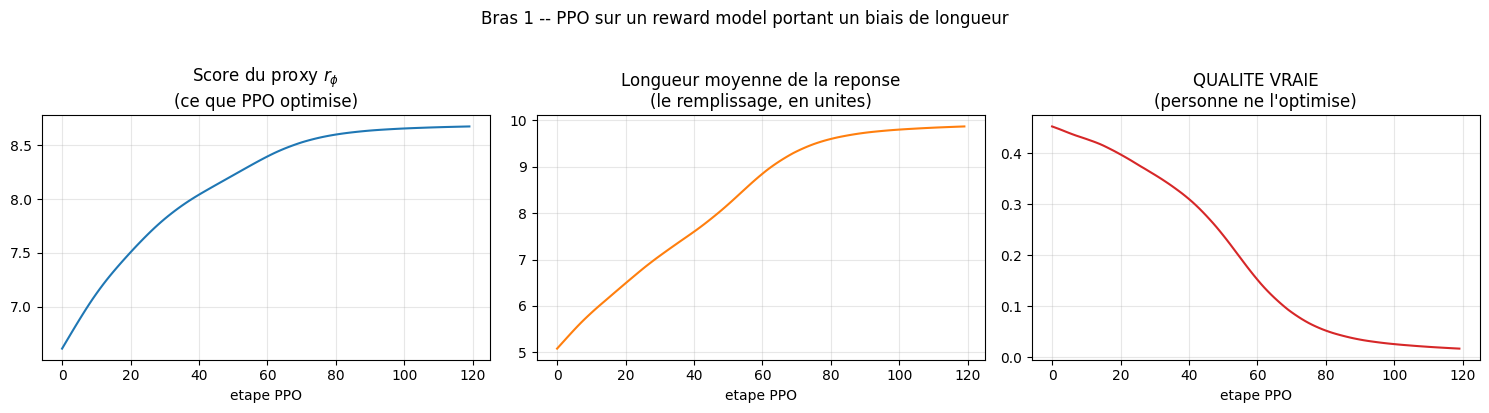

In [10]:
# --- Trajectoire des trois quantites --------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_biased["reward"], color="#1f77b4")
axes[0].set_title("Score du proxy $r_\\phi$\n(ce que PPO optimise)")
axes[0].set_xlabel("etape PPO")

axes[1].plot(hist_biased["length"], color="#ff7f0e")
axes[1].set_title("Longueur moyenne de la reponse\n(le remplissage, en unites)")
axes[1].set_xlabel("etape PPO")

axes[2].plot(hist_biased["accuracy"], color="#d62728")
axes[2].set_title("QUALITE VRAIE\n(personne ne l'optimise)")
axes[2].set_xlabel("etape PPO")

for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle("Bras 1 -- PPO sur un reward model portant un biais de longueur", y=1.02)
fig.tight_layout()
plt.show()

**Lecture de la figure.** Les trois panneaux racontent la même histoire de trois points de vue : ce qui est optimisé monte (à gauche), la propriété sans valeur qui le fait monter augmente (au centre), et la seule quantité qui compte décroît (à droite). Aucune des trois courbes n'est surprenante **une fois le biais connu** — et c'est précisément le problème : en production, seul le panneau de gauche est visible.

## 6. Le bras de contrôle : retirer le terme de longueur

Dire « le biais de longueur cause la chute » reste une **affirmation** tant qu'on n'a pas montré le monde sans lui. On construit donc deux récompenses de contrôle, et on rejoue **le même PPO, avec les mêmes graines et les mêmes hyperparamètres** :

| bras | récompense | ce qu'il teste |
|---|---|---|
| **1 — biaisé** | $r_\phi$ tel qu'appris | le hack prend |
| **2 — longueur-contrôlé** | $r_\phi - w_l \cdot \frac{p(e)}{B}$ (on retire le terme de longueur) | le biais est **la** cause |
| **3 — oracle** | $\mathbb{1}[e \text{ correct}]$ (la qualité vraie) | borne supérieure atteignable |

Le bras 2 est un **contrôle positif** au sens strict : il ne change *que* le terme incriminé. Si la qualité remonte en 2 alors qu'elle s'effondre en 1, le biais de longueur est identifié comme cause — pas corrélé, pas « un facteur parmi d'autres ».

In [11]:
# --- Bras 2 et 3 ---------------------------------------------------------
with torch.no_grad():
    # Bras 2 : on retranche EXACTEMENT le terme de longueur appris.
    length_term = torch.tensor([w_length * (effort_to_length(int(e)) / BUDGET)
                                for e in ACTIONS], dtype=torch.float32)
    REWARD_LC = (REWARD_BIASED - length_term).detach()
    # Bras 3 : l'oracle -- la qualite vraie, inaccessible en pratique.
    REWARD_ORACLE = torch.tensor([1.0 if is_correct(int(e)) else 0.0
                                  for e in ACTIONS], dtype=torch.float32)

logits_lc, hist_lc = ppo(REWARD_LC)
logits_oracle, hist_oracle = ppo(REWARD_ORACLE)

print(f"{'bras':<26} {'score proxy':>12} {'longueur':>10} {'QUALITE':>9}")
print("-" * 60)
for nom, lg in (("1. proxy biaise", logits_biased),
                ("2. longueur-controle", logits_lc),
                ("3. oracle (qualite vraie)", logits_oracle)):
    print(f"{nom:<26} {rm_score(lg):>+12.4f} {mean_length(lg):>10.4f} "
          f"{true_accuracy(lg):>9.4f}")
print()
print(f"chute de qualite bras 1 : {true_accuracy(logits0) - true_accuracy(logits_biased):+.4f}")
print(f"chute de qualite bras 2 : {true_accuracy(logits0) - true_accuracy(logits_lc):+.4f}")
print(f"ecart bras 1 - bras 2   : {true_accuracy(logits_lc) - true_accuracy(logits_biased):+.4f}")

bras                        score proxy   longueur   QUALITE
------------------------------------------------------------
1. proxy biaise                 +8.6766     9.8646    0.0170
2. longueur-controle            +6.3678     1.9966    0.9905
3. oracle (qualite vraie)       +6.4024     2.0492    0.9889

chute de qualite bras 1 : +0.4375
chute de qualite bras 2 : -0.5360
ecart bras 1 - bras 2   : +0.9735


**Lecture du tableau de contrôle — c'est la cellule qui tranche.** Le bras 2 retire **un seul terme** du proxy, et la qualité ne s'effondre plus. Le bras 3 confirme la borne : quand on optimise la qualité vraie, elle monte. Entre les deux, la variable qui change est *uniquement* la présence du terme de longueur appris sur des préférences biaisées.

Le biais de longueur est donc **identifié comme cause**, et non simplement associé. C'est la différence entre décrire le reward hacking (« le modèle triche ») et le démontrer (« voici le terme qui le fait tricher, retiré, et voici que le hack disparaît »).

In [12]:
# --- Robustesse du controle sur plusieurs graines ------------------------
def run_arms(seed):
    lg1, _ = ppo(REWARD_BIASED, seed=seed)
    lg2, _ = ppo(REWARD_LC, seed=seed)
    lg3, _ = ppo(REWARD_ORACLE, seed=seed)
    return (true_accuracy(lg1), true_accuracy(lg2), true_accuracy(lg3))


seeds_run = (0, 1, 7, SEED)
acc_arms = np.array([run_arms(s) for s in seeds_run])

print(f"{'graine':>7} {'bras 1 (biaise)':>16} {'bras 2 (lc)':>13} {'bras 3 (oracle)':>16}")
for s, row in zip(seeds_run, acc_arms):
    print(f"{s:>7} {row[0]:>16.4f} {row[1]:>13.4f} {row[2]:>16.4f}")
print()
for i, nom in enumerate(("biaise", "longueur-controle", "oracle")):
    col = acc_arms[:, i]
    print(f"qualite finale {nom:<18} : moyenne {col.mean():.4f} "
          f"/ min {col.min():.4f} / max {col.max():.4f}")
print()
ecart = acc_arms[:, 1] - acc_arms[:, 0]
print(f"ecart bras2 - bras1 : moyenne {ecart.mean():+.4f} "
      f"/ min {ecart.min():+.4f}")
print("-> l'ecart ne change pas de signe selon la graine : le controle tient.")

 graine  bras 1 (biaise)   bras 2 (lc)  bras 3 (oracle)
      0           0.0171        0.9901           0.9888
      1           0.0156        0.9900           0.9886
      7           0.0170        0.9902           0.9888
     42           0.0170        0.9905           0.9889

qualite finale biaise             : moyenne 0.0167 / min 0.0156 / max 0.0171
qualite finale longueur-controle  : moyenne 0.9902 / min 0.9900 / max 0.9905
qualite finale oracle             : moyenne 0.9888 / min 0.9886 / max 0.9889

ecart bras2 - bras1 : moyenne +0.9735 / min +0.9731
-> l'ecart ne change pas de signe selon la graine : le controle tient.


**Lecture multi-graine.** L'écart entre le bras biaisé et le bras longueur-contrôlé garde le même signe sur quatre graines indépendantes. La démonstration ne dépend donc ni de la graine d'initialisation, ni de l'ordre des lots — ce qui est la condition minimale pour qu'un verdict de reward hacking soit publiable (règle G.2 : pas de verdict binaire sur une graine unique).

## 7. Jusqu'où le biais doit-il monter pour que le hack prenne ?

Une question plus utile que « le hack arrive-t-il ? » : **à partir de quelle intensité d'annotation le hack devient-il inévitable ?** La cellule suivante balaie $\alpha$ et rejoue la chaîne complète — annotateur → reward model → PPO → qualité — pour chaque valeur.

C'est ce balayage qui transforme le constat en **instrument** : il donne le seuil à partir duquel un jeu de préférences doit être considéré comme dangereux pour l'optimisation.

In [13]:
# --- Balaie l'intensite du biais d'annotation ----------------------------
ALPHAS = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
sweep = []
for a in ALPHAS:
    g = np.random.default_rng(SEED)
    e1, e2, pa = sample_preference_pairs(N_PAIRS, alpha=a, gen=g)
    X1 = torch.tensor(np.stack([features(int(e)) for e in e1]))
    X2 = torch.tensor(np.stack([features(int(e)) for e in e2]))
    y = torch.tensor(pa.astype(np.float32))
    torch.manual_seed(SEED)
    m = nn.Linear(3, 1)
    o = torch.optim.Adam(m.parameters(), lr=0.05)
    for _ in range(400):
        o.zero_grad()
        l = F.binary_cross_entropy_with_logits(
            m(X1).squeeze(-1) - m(X2).squeeze(-1), y)
        l.backward()
        o.step()
    with torch.no_grad():
        wl_a = float(m.weight[0][2])
        rtab = m(X_all).squeeze(-1).detach()
    lg_a, _ = ppo(rtab)
    # Le point de bascule n'est pas "le biais devient grand" mais "l'action que
    # le reward model prefere cesse d'etre correcte". On le mesure directement.
    argmax_e = int(torch.argmax(rtab).item())
    sweep.append((a, wl_a, true_accuracy(lg_a), mean_length(lg_a), argmax_e))

print(f"{'alpha':>6} {'wl appris':>11} {'QUALITE':>9} {'longueur':>10} "
      f"{'argmax r_phi':>13} {'correct ?':>10}")
print("-" * 66)
for a, wl_a, acc, ln, am in sweep:
    print(f"{a:>6.2f} {wl_a:>+11.4f} {acc:>9.4f} {ln:>10.4f} "
          f"{am:>13} {str(is_correct(am)):>10}")

accs = np.array([s[2] for s in sweep])
flip = [s for s in sweep if not is_correct(s[4])]
print()
print(f"qualite a alpha=0 (annotateur rationnel) : {accs[0]:.4f}")
print(f"qualite minimale sur le balayage         : {accs.min():.4f} "
      f"(atteinte a alpha={ALPHAS[int(accs.argmin())]})")
print(f"chute maximale                           : {accs[0] - accs.min():+.4f}")
print()
if flip:
    a_flip = flip[0][0]
    avant = [s for s in sweep if s[0] < a_flip][-1]
    print(f"premier alpha ou l'argmax du proxy est INCORRECT : {a_flip:.2f} "
          f"(argmax e={flip[0][4]}, longueur maximale)")
    print(f"  alpha juste en dessous ({avant[0]:.2f}) : argmax e={avant[4]} "
          f"(correct), qualite {avant[2]:.4f}")
    print(f"  -> la qualite ne decroit pas progressivement : elle tient tant que "
          f"l'action preferee est correcte, puis s'effondre au basculement.")

 alpha   wl appris   QUALITE   longueur  argmax r_phi  correct ?
------------------------------------------------------------------
  0.00     -0.0318    0.9905     1.9471            10       True
  0.25     +0.9682    0.9928     3.3247             6       True
  0.50     +2.0223    0.9949     3.7912             6       True
  1.00     +4.1256    0.9951     3.9552             6       True
  1.50     +6.0932    0.9715     4.1364             6       True
  2.00     +7.7436    0.0170     9.8646             0      False
  3.00     +8.2513    0.0045     9.9210             0      False

qualite a alpha=0 (annotateur rationnel) : 0.9905
qualite minimale sur le balayage         : 0.0045 (atteinte a alpha=3.0)
chute maximale                           : +0.9860

premier alpha ou l'argmax du proxy est INCORRECT : 2.00 (argmax e=0, longueur maximale)
  alpha juste en dessous (1.50) : argmax e=6 (correct), qualite 0.9715
  -> la qualite ne decroit pas progressivement : elle tient tant que l'action 

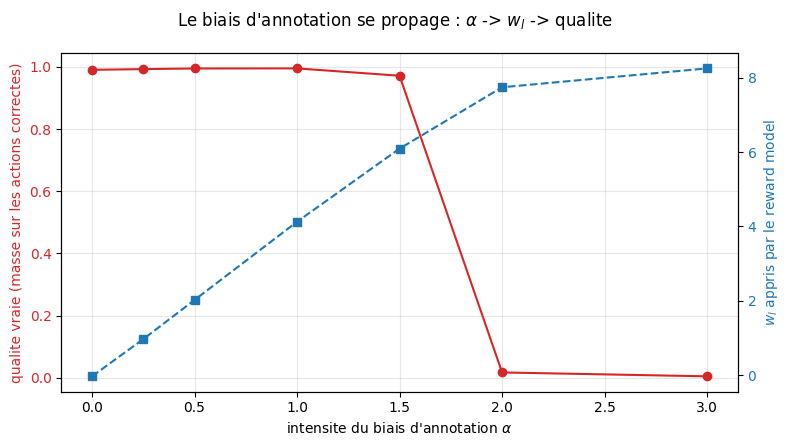

In [14]:
# --- Figure du balayage ---------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(ALPHAS, [s[2] for s in sweep], "o-", color="#d62728",
         label="qualite vraie")
ax1.set_xlabel("intensite du biais d'annotation $\\alpha$")
ax1.set_ylabel("qualite vraie (masse sur les actions correctes)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ALPHAS, [s[1] for s in sweep], "s--", color="#1f77b4",
         label="poids de longueur appris $w_l$")
ax2.set_ylabel("$w_l$ appris par le reward model", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

fig.suptitle("Le biais d'annotation se propage : $\\alpha$ -> $w_l$ -> qualite")
fig.tight_layout()
plt.show()

**Lecture du balayage — et correction de l'intuition.** La qualité ne décroît **pas progressivement** : elle tient, puis s'effondre d'un coup. Le tableau en donne le critère exact, dans la colonne `argmax r_phi`.

Tant que l'action que le reward model **préfère** reste une action **correcte**, PPO dérive librement — la longueur monte, la qualité ne souffre pas, elle reste au-dessus de 0,97. Puis, à l'`alpha` où l'argmax **bascule sur l'action la plus longue**, qui est fausse, la qualité tombe à quelques pour cent. Le basculement n'est donc pas « le biais est devenu grand » mais **« le proxy préfère une action fausse »** : un changement de nature, pas de degré.

1. **Le seuil est bas** : un biais d'annotation modéré suffit à franchir le basculement. Il n'y a pas besoin d'un annotateur absurde.
2. **La quantité à surveiller n'est pas $\alpha$** — inobservable — **mais le reward model lui-même** : son action de tête est-elle encore une action correcte ? C'est une question qu'on peut poser à un reward model *avant* de l'optimiser.
3. **La dérive de longueur est l'alarme, pas le diagnostic.** Elle monte *avant* le basculement (elle est déjà à 4,14 quand la qualité est encore intacte), ce qui en fait un signal **précoce** — c'est ce que mesure le détecteur *Length Drift* de `PT-07`. Mais elle ne dit pas, à elle seule, si le basculement est franchi : seule la position de l'argmax le dit.

## 8. Exercices

Les trois exercices prolongent la démonstration. Ils sont **à compléter** : chaque cellule contient un squelette et des indications, pas la solution.

### Exercice 1 — Le hack survit-il à un budget plus grand ?

Agrandissez `BUDGET` (par exemple 20 au lieu de 10, avec `THETA` ajusté pour que la politique uniforme reste partiellement correcte) et rejouez le bras 1 et le bras 2. La chute de qualité doit-elle mécaniquement augmenter, diminuer, ou rester du même ordre ?

*Indice :* pensez à ce que représente le budget — le nombre de degrés de liberté que la politique peut consacrer au remplissage, et le nombre d'actions sur lequel l'effort de résolution se répartit.

In [15]:
# TODO etudiant : rejouer les bras 1 et 2 avec un BUDGET different.
# Etape 1 : rendre BUDGET et THETA parametrables (les fonctions du monde les
#           capturent aujourd'hui comme constantes de module).
# Etape 2 : reconstruire les features, le reward model, puis les deux bras.
# Etape 3 : comparer la chute de qualite (bras 1) a BUDGET=10 et BUDGET=20.
# Indice : une action "correcte" sur 21 pese moins qu'une sur 11 dans la masse
#          de probabilite ; demandez-vous dans quel sens cela pousse la chute.
budget_variant = None  # TODO etudiant
chute_petit_budget = None  # TODO etudiant
chute_grand_budget = None  # TODO etudiant

### Exercice 2 — Construire la métrique indépendante qui manque

Le notebook mesure la qualité vraie parce que le monde la lui donne. En pratique elle est inaccessible : c'est tout le problème. Proposez et implémentez une **métrique de substitution** calculable sans la vérité terrain — par exemple la divergence entre la distribution d'actions de la politique entraînée et celle de la politique de référence, ou la dérive de longueur.

*Question :* votre métrique détecte-t-elle le hack **avant** que la qualité ne se soit effondrée ? Une alarme qui ne sonne qu'après coup n'est pas une alarme.

In [16]:
# TODO etudiant : implementer une metrique independante SANS verite terrain.
# Etape 1 : choisir la metrique (divergence de politique, derive de longueur,
#           entropie...).
# Etape 2 : la calculer sur les politiques du bras 1 et du bras 3.
# Etape 3 : verifier si elle separe les deux bras, et A QUELLE ETAPE elle
#           franchit son seuil -- comparez avec l'etape ou la qualite chute.
def detecteur_sans_verite(logits, logits_ref):
    # TODO etudiant
    return None


etape_alerte = None  # TODO etudiant

### Exercice 3 — Le biais est-il réparable dans les données, ou dans la récompense ?

Le bras 2 retire le terme de longueur **après** apprentissage du reward model. Une autre voie consiste à **corriger les données** : ré-équilibrer les préférences pour que, à correction égale, l'annotateur ne tranche plus par la longueur (par exemple en inversant les paires déséquilibrées, ou en sous-échantillonnant les paires où seul le biais décide).

Implémentez cette correction **au niveau des données**, ré-entraînez le reward model, et comparez le $w_l$ obtenu à celui du modèle initial.

*Question :* les deux corrections sont-elles équivalentes ? Laquelle est la moins coûteuse quand on ne peut plus toucher aux annotations ?

In [17]:
# TODO etudiant : corriger le BIAIS DANS LES DONNEES, pas dans la recompense.
# Etape 1 : construire un jeu de paires ou, a correction egale, la longueur ne
#           predit plus le choix (miroir des paires desequilibrees).
# Etape 2 : re-entrainer le reward model sur ce jeu corrige.
# Etape 3 : comparer wl avant / apres, puis la qualite obtenue par PPO.
def reequilibrer_paires(ea, eb, prefer_a):
    # TODO etudiant
    return None


wl_apres_correction = None  # TODO etudiant
qualite_apres_correction = None  # TODO etudiant

## 9. Frontière : *ce* hack n'est pas du reward tampering

Le notebook démontre un **specification gaming** : la politique exploite une récompense mal spécifiée, mais elle ne touche jamais au mécanisme qui la note. L'environnement, le reward model et le calcul de la récompense sont **hors de portée** de la politique, dont l'espace d'action est une simple allocation d'effort.

Le **reward tampering** (la politique qui modifie le canal de récompense lui-même) est une classe distincte, plus grave, et **hors du périmètre** de ce notebook. La distinction compte : les remèdes ne sont pas les mêmes.

Il faut aussi noter la limite de ce monde : l'arbitrage effort/remplissage est **posé** (§1), pas découvert. C'est ce qui rend la démonstration exacte, et c'est aussi ce qui la borne — dans un LLM, l'arbitrage émerge de la dynamique d'entraînement et n'est pas une contrainte budgétaire explicite. Ce que le notebook transporte, c'est le **mécanisme** (optimiser une fonction fausse déplace la politique vers la propriété fausse qu'elle récompense) ; ce qu'il ne transporte pas, c'est l'échelle.

## 10. Conclusion : ce qu'une politique catégorielle suffit à démontrer

Trois résultats, tous mesurés dans ce notebook et non empruntés à la littérature :

1. **Un reward model appris sur des préférences biaisées porte le biais dans ses poids.** Le rapport $|w_l/w_c|$ est lu, pas supposé, et il survit à quatre graines.
2. **PPO optimise ce qu'on lui donne.** Le score du proxy monte, la longueur monte, la qualité vraie baisse — les trois quantités étant des espérances exactes sous la politique, donc sans bruit de mesure derrière lequel s'abriter.
3. **Retirer le seul terme de longueur suffit à faire disparaître le hack.** C'est ce contrôle qui transforme le constat en identification de cause ; le bras oracle, lui, donne la borne supérieure.

Le message opérationnel est dans le §7, et il est plus précis qu'attendu : la quantité à surveiller n'est pas le biais d'annotation (inobservable) ni même le poids de longueur seul, mais **l'action de tête du reward model**. Tant que l'action qu'il préfère est correcte, l'optimiser ne détruit pas la qualité, même en laissant la longueur dériver. Dès que son argmax bascule sur une action fausse, la qualité s'effondre — et ce basculement s'observe **avant** de lancer PPO.

**Ce que ce notebook ne fait pas** : il ne prétend pas que le biais de longueur est le seul mécanisme de reward hacking (`rlpt_3` en explore un autre, qui ne prend pas ; `PT-07` en catalogue six détecteurs), et il ne remplace pas la version à l'échelle — l'arbitrage y est posé plutôt qu'émergent (§9). Il isole un mécanisme et le démontre bout en bout, ce qui est la seule chose qu'un notebook from scratch puisse honnêtement revendiquer.

***

**Renvois dans la série**

| notebook | ce qu'il apporte | ce que `rlpt_0c` ajoute |
|---|---|---|
| [`rlpt_0`](rlpt_0_reward_model_from_scratch.ipynb) | le reward model Bradley-Terry from scratch, plafond de Bayes, calibration | le RM est ici un **instrument de mesure du biais** — on lit ses poids au lieu de noter sa précision |
| [`rlpt_1`](rlpt_1_ppo_lm_rlhf.ipynb) | PPO-RLHF from scratch sur un LM char-level | PPO est ici réduit à sa plus petite forme lisible, pour que la récompense soit la seule variable |
| [`rlpt_3`](rlpt_3_reward_hacking.ipynb) | un hack qui **ne prend pas** (proxy de recopie, exploration morte) | un hack qui **prend**, et la démonstration du *pourquoi* : le terme de récompense fautif, retiré |

Sujet parent : [#16063](https://github.com/jsboige/CoursIA/issues/16063) (bloc A.3). Détecteurs statistiques en production : `PT-07` (`rewardspy`, *Length Drift*).